In [1]:
# Environment setup

import sys

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    ENV = "colab"
    print("Running on Google Colab")
else:
    ENV = "local"
    print("Running locally")

Running on Google Colab


In [2]:
if ENV == "colab":

    print("Install dependencies")
    !pip install -q pytorch-msssim torchsummary

    # Library Imports
    import time
    from scipy import ndimage
    import numpy as np
    import matplotlib.pyplot as plt
    import os
    import random
    import seaborn as sns
    import sys
    import struct
    from scipy import interpolate

    import torch
    import torch.nn as nn
    from pytorch_msssim import ssim
    from torch.utils.data import Dataset, DataLoader
    from torch.optim import Adam

    from sklearn.model_selection import train_test_split
    from sklearn.feature_extraction.image import extract_patches_2d

    from torchsummary import summary

else:
    import time
    from scipy import ndimage
    import numpy as np
    import matplotlib.pyplot as plt
    import os
    import random
    import seaborn as sns
    import sys
    import struct
    from scipy import interpolate
    import torch
    import torch.nn as nn
    from pytorch_msssim import ssim
    from torch.utils.data import Dataset
    from sklearn.model_selection import train_test_split
    from torch.utils.data import DataLoader
    from torch.optim import Adam
    from sklearn.feature_extraction.image import extract_patches_2d
    from torchsummary import summary

Install dependencies


In [3]:
# Device Configuration: use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [4]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [5]:
print(os.getcwd())
print(os.listdir())

/content
['.config', 'gdrive', 'sample_data']


In [6]:
DATA_DIR = '/content/gdrive/MyDrive/scimlga2026/lab01_TreinoRedeTirosRecFreq/'
os.chdir(DATA_DIR)
!ls

model_l1_freq.pth	      model_mse_train_loss.npy
model_l1_freq_train_loss.npy  model_mse_val_loss.npy
model_l1_freq_val_loss.npy    treino_rede_recfreq.ipynb
model_mse.pth


In [7]:
x_data= np.load('../resources_FiltragemTiros/input.npy')
y_data= np.load('../resources_FiltragemTiros/output.npy')
y_data=y_data[::4,:,:]/np.amax(abs(y_data))
x_data=x_data[::4,:,:]/np.amax(abs(x_data))

In [8]:
img_train, x_test, mask_train, y_test = train_test_split(np.expand_dims(x_data,axis=1),np.expand_dims(y_data, axis=1),test_size=0.05,random_state=42)
#cria patches das imagens separadas para treino e validação
img_patches=[]
mask_patches=[]
patchshape=(64,64)
numpatches=5
for ind in range(img_train.shape[0]):
    for j in range(numpatches):
        i=np.random.randint(0,2000)
        patches_x = extract_patches_2d(img_train[ind,0,:,:], patchshape,max_patches=10, random_state=i)
        patches_y = extract_patches_2d(mask_train[ind,0,:,:],patchshape,max_patches=10, random_state=i)
        img_patches.append(patches_x)
        mask_patches.append(patches_y)
img_patches=np.expand_dims(np.concatenate(img_patches),axis=1)
mask_patches=np.expand_dims(np.concatenate(mask_patches),axis=1)
del img_train
del mask_train

In [9]:
BATCH = 32
x_train, x_val, y_train, y_val = train_test_split(img_patches,mask_patches,test_size=1/8,random_state=42)
class ImageDataset(Dataset):
    def __init__(self, images, masks):
        self.images = torch.tensor(images,dtype=torch.float32)
        self.masks = torch.tensor(masks,dtype=torch.float32)
    def __len__(self):
        return len(self.images)
    def __getitem__(self, idx):
        return self.images[idx], self.masks[idx]
train_dataset = ImageDataset(x_train,y_train)

val_dataset = ImageDataset(x_val,y_val)
train_loader = DataLoader(train_dataset,batch_size=BATCH,shuffle=True)
val_loader = DataLoader(val_dataset,batch_size=BATCH,shuffle=False)

In [10]:
class Conv2dBlock(nn.Module):
    def __init__(self, in_channels, out_channels,
                 kernel_size=3,
                 batchnorm=False,
                 momentum=0.9):
        super().__init__()
        layers = []
        layers.append(
            nn.Conv2d(in_channels,out_channels,kernel_size=kernel_size,padding="same",bias=not batchnorm)
        )

        if batchnorm:
            layers.append(
                nn.BatchNorm2d(out_channels,momentum=1 - momentum)
            )

        layers.append(nn.ReLU(inplace=True))
        layers.append(
            nn.Conv2d(out_channels,out_channels,kernel_size=kernel_size,padding="same",bias=not batchnorm)
        )
        if batchnorm:
            layers.append(
                nn.BatchNorm2d(out_channels,momentum=0.1)
            )

        layers.append(nn.ReLU(inplace=True))
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)

In [11]:
class UNet(nn.Module):
    def __init__(
        self,
        in_channels=1,
        output_filters=1,
        n_filters=16,
        dropout=0.2,
        batchnorm=True,
        moment=0.9
    ):
        super().__init__()

        # Encoder
        self.c1 = Conv2dBlock(in_channels,n_filters,kernel_size=5,batchnorm=batchnorm,momentum=moment)

        self.c2 = Conv2dBlock(n_filters,n_filters * 2,kernel_size=5,batchnorm=batchnorm,momentum=moment)

        self.c3 = Conv2dBlock(n_filters * 2,n_filters * 4,kernel_size=5,batchnorm=batchnorm,momentum=moment)

        self.c4 = Conv2dBlock(n_filters * 4,n_filters * 8,kernel_size=5,batchnorm=batchnorm,momentum=moment)

        self.c5 = Conv2dBlock(n_filters * 8,n_filters * 16,kernel_size=5,batchnorm=batchnorm,momentum=moment)

        self.pool = nn.MaxPool2d(2)
        self.drop = nn.Dropout2d(dropout)

        # Decoder
        self.up6 = nn.ConvTranspose2d(n_filters * 16,n_filters * 16,kernel_size=3,stride=2, padding=1,output_padding=1)

        self.up7 = nn.ConvTranspose2d(n_filters * 8,n_filters * 8,kernel_size=3,stride=2,padding=1,output_padding=1)

        self.up8 = nn.ConvTranspose2d(n_filters * 4,n_filters * 4,kernel_size=3,stride=2,padding=1,output_padding=1)

        self.up9 = nn.ConvTranspose2d(n_filters * 2,n_filters*2,kernel_size=3,stride=2,padding=1,output_padding=1)

        self.c6 = Conv2dBlock(n_filters * 16+n_filters * 8,n_filters * 8,kernel_size=3,batchnorm=batchnorm,momentum=moment)

        self.c7 = Conv2dBlock(n_filters * 8+n_filters * 4,n_filters * 4,kernel_size=3,batchnorm=batchnorm,momentum=moment)

        self.c8 = Conv2dBlock(n_filters * 4+n_filters * 2,n_filters * 2,kernel_size=3,batchnorm=batchnorm,momentum=moment)

        self.c9 = Conv2dBlock(n_filters * 2+1,n_filters,kernel_size=3,batchnorm=batchnorm,momentum=moment) #modificado para passagem da entrada

        self.out = nn.Conv2d(n_filters,output_filters,kernel_size=1)

    def forward(self, x):

        c1 = self.c1(x)
        p1 = self.drop(self.pool(c1))

        c2 = self.c2(p1)
        p2 = self.drop(self.pool(c2))

        c3 = self.c3(p2)
        p3 = self.drop(self.pool(c3))

        c4 = self.c4(p3)
        p4 = self.drop(self.pool(c4))

        c5 = self.c5(p4)

        u6 = self.up6(c5)
        u6 = torch.cat([u6, c4], dim=1)
        u6 = self.drop(u6)
        c6 = self.c6(u6)

        u7 = self.up7(c6)
        u7 = torch.cat([u7, c3], dim=1)
        u7 = self.drop(u7)
        c7 = self.c7(u7)

        u8 = self.up8(c7)
        u8 = torch.cat([u8, c2], dim=1)
        u8 = self.drop(u8)
        c8 = self.c8(u8)

        u9 = self.up9(c8)
        u9 = torch.cat([u9, x], dim=1)#passagem da entrada para os blocos finais
        u9 = self.drop(u9)
        c9 = self.c9(u9)

        return self.out(c9)

In [12]:
class UNetUp(nn.Module):
    def __init__(
        self,
        in_channels=1,
        output_filters=1,
        n_filters=16,
        dropout=0.2,
        batchnorm=True,
        moment=0.9
    ):
        super().__init__()

        # Encoder
        self.c1 = Conv2dBlock(in_channels,n_filters,kernel_size=5,batchnorm=batchnorm,momentum=moment)

        self.c2 = Conv2dBlock(n_filters,n_filters * 2,kernel_size=5,batchnorm=batchnorm,momentum=moment)

        self.c3 = Conv2dBlock(n_filters * 2,n_filters * 4,kernel_size=5,batchnorm=batchnorm,momentum=moment)

        self.c4 = Conv2dBlock(n_filters * 4,n_filters * 8,kernel_size=5,batchnorm=batchnorm,momentum=moment)

        self.c5 = Conv2dBlock(n_filters * 8,n_filters * 16,kernel_size=5,batchnorm=batchnorm,momentum=moment)

        self.pool = nn.MaxPool2d(2)
        self.drop = nn.Dropout2d(dropout)

        # Decoder
        self.up6 = nn.Upsample(scale_factor=2,mode='bilinear',align_corners=False)

        self.up7 = nn.Upsample(scale_factor=2,mode='bilinear',align_corners=False)

        self.up8 = nn.Upsample(scale_factor=2,mode='bilinear',align_corners=False)

        self.up9 = nn.Upsample(scale_factor=2,mode='bilinear',align_corners=False)

        self.c6 = Conv2dBlock(n_filters * 16+n_filters * 8,n_filters * 8,kernel_size=3,batchnorm=batchnorm,momentum=moment)

        self.c7 = Conv2dBlock(n_filters * 8+n_filters * 4,n_filters * 4,kernel_size=3,batchnorm=batchnorm,momentum=moment)

        self.c8 = Conv2dBlock(n_filters * 4+n_filters * 2,n_filters * 2,kernel_size=3,batchnorm=batchnorm,momentum=moment)

        self.c9 = Conv2dBlock(n_filters * 2+1,n_filters,kernel_size=3,batchnorm=batchnorm,momentum=moment)
        self.out = nn.Conv2d(n_filters,output_filters,kernel_size=1)

    def forward(self, x):

        c1 = self.c1(x)
        p1 = self.drop(self.pool(c1))

        c2 = self.c2(p1)
        p2 = self.drop(self.pool(c2))

        c3 = self.c3(p2)
        p3 = self.drop(self.pool(c3))

        c4 = self.c4(p3)
        p4 = self.drop(self.pool(c4))

        c5 = self.c5(p4)

        u6 = self.up6(c5)
        u6 = torch.cat([u6, c4], dim=1)
        u6 = self.drop(u6)
        c6 = self.c6(u6)

        u7 = self.up7(c6)
        u7 = torch.cat([u7, c3], dim=1)
        u7 = self.drop(u7)
        c7 = self.c7(u7)

        u8 = self.up8(c7)
        u8 = torch.cat([u8, c2], dim=1)
        u8 = self.drop(u8)
        c8 = self.c8(u8)

        u9 = self.up9(c8)
        u9 = torch.cat([u9, x], dim=1)#passagem da entrada para os blocos finais
        u9 = self.drop(u9)
        c9 = self.c9(u9)

        return self.out(c9)

In [13]:
class FreqLoss(torch.nn.Module):
    def __init__(self,patch_size):
        super().__init__()
        self.patch_size=patch_size

    def forward(self, pred, label):

        pred_sp  = torch.fft.rfft(torch.nn.functional.pad(pred,(0,0,1024-self.patch_size[0],0), "constant", 0),axis=2)
        label_sp = torch.fft.rfft(torch.nn.functional.pad(label,(0,0,1024-self.patch_size[0],0), "constant", 0),axis=2)
        return torch.mean(torch.abs(torch.abs(pred_sp)-torch.abs(label_sp)))

In [14]:
EPOCAS=100
BATCH = 32
PATIENCE = 15
model = UNet(in_channels=1, n_filters=16,dropout=0.2,moment=0.2,batchnorm=False)
model = model.to(device)
summary(model,input_size=(1, 64, 64))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 16, 64, 64]             416
              ReLU-2           [-1, 16, 64, 64]               0
            Conv2d-3           [-1, 16, 64, 64]           6,416
              ReLU-4           [-1, 16, 64, 64]               0
       Conv2dBlock-5           [-1, 16, 64, 64]               0
         MaxPool2d-6           [-1, 16, 32, 32]               0
         Dropout2d-7           [-1, 16, 32, 32]               0
            Conv2d-8           [-1, 32, 32, 32]          12,832
              ReLU-9           [-1, 32, 32, 32]               0
           Conv2d-10           [-1, 32, 32, 32]          25,632
             ReLU-11           [-1, 32, 32, 32]               0
      Conv2dBlock-12           [-1, 32, 32, 32]               0
        MaxPool2d-13           [-1, 32, 16, 16]               0
        Dropout2d-14           [-1, 32,

In [15]:
criterion = nn.MSELoss()
modelpath='model_mse'
#criterion1 = nn.L1Loss()
#criterion2 = AmpLoss(patchshape)
optimizer = Adam(model.parameters(),lr=1e-4,weight_decay=2e-4)

best_val_loss = float("inf")
counter = 0
train_losses = []
val_losses = []
train_maes = []
val_maes = []
for epoch in range(EPOCAS):
    # ======================
    # TREINO
    # ======================
    model.train()
    running_loss = 0.0
    running_mae = 0.0
    for images, targets in train_loader:
        images = images.to(device)
        targets = targets.to(device)
        optimizer.zero_grad()
        outputs = model(images)
 #       loss = criterion1(outputs, targets)+0.01*criterion2(outputs, targets)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        mae = torch.mean(torch.abs(outputs - targets))
        running_loss += loss.item()
        running_mae += mae.item()

    epoch_train_loss = running_loss / len(train_loader)
    epoch_train_mae = running_mae / len(train_loader)
    # ======================
    # VALIDAÇÃO
    # ======================
    model.eval()
    running_val_loss = 0.0
    running_val_mae = 0.0
    with torch.no_grad():
        for images, targets in val_loader:
            images = images.to(device)
            targets = targets.to(device)
            outputs = model(images)
            #loss = criterion1(outputs, targets)+0.01*criterion2(outputs, targets)
            loss = criterion(outputs, targets)
            mae = torch.mean(torch.abs(outputs - targets))
            running_val_loss += loss.item()
            running_val_mae += mae.item()
    epoch_val_loss = running_val_loss / len(val_loader)
    epoch_val_mae = running_val_mae / len(val_loader)

    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)
    train_maes.append(epoch_train_mae)
    val_maes.append(epoch_val_mae)

    print(
        f"Epoch [{epoch+1}/{EPOCAS}] "
        f"loss={epoch_train_loss:.4f} "
        f"mae={epoch_train_mae:.4f} "
        f"val_loss={epoch_val_loss:.4f} "
        f"val_mae={epoch_val_mae:.4f}"
    )

    # ======================
    # MODEL CHECKPOINT
    # ======================
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(),modelpath+'.pth')
        print(f"Val loss melhorou para {best_val_loss:.6f}. "f"Salvando modelo.")
        counter = 0
    else:
        counter += 1

        print(f"Val loss não melhorou. "f"Patience {counter}/{PATIENCE}")

        # ======================
        # EARLY STOPPING
        # ======================
        if counter >= PATIENCE:

            print("Early stopping!")
            break
np.save(modelpath+"_val_loss.npy", val_losses)
np.save(modelpath+"_train_loss.npy", train_losses)

Epoch [1/100] loss=0.0126 mae=0.0866 val_loss=0.0019 val_mae=0.0232
Val loss melhorou para 0.001889. Salvando modelo.
Epoch [2/100] loss=0.0016 mae=0.0262 val_loss=0.0010 val_mae=0.0162
Val loss melhorou para 0.000956. Salvando modelo.
Epoch [3/100] loss=0.0010 mae=0.0199 val_loss=0.0006 val_mae=0.0125
Val loss melhorou para 0.000626. Salvando modelo.
Epoch [4/100] loss=0.0007 mae=0.0168 val_loss=0.0005 val_mae=0.0118
Val loss melhorou para 0.000481. Salvando modelo.
Epoch [5/100] loss=0.0006 mae=0.0147 val_loss=0.0004 val_mae=0.0103
Val loss melhorou para 0.000405. Salvando modelo.
Epoch [6/100] loss=0.0006 mae=0.0135 val_loss=0.0004 val_mae=0.0106
Val loss melhorou para 0.000376. Salvando modelo.
Epoch [7/100] loss=0.0005 mae=0.0122 val_loss=0.0003 val_mae=0.0108
Val loss melhorou para 0.000340. Salvando modelo.
Epoch [8/100] loss=0.0005 mae=0.0116 val_loss=0.0003 val_mae=0.0095
Val loss melhorou para 0.000323. Salvando modelo.
Epoch [9/100] loss=0.0004 mae=0.0109 val_loss=0.0003 val

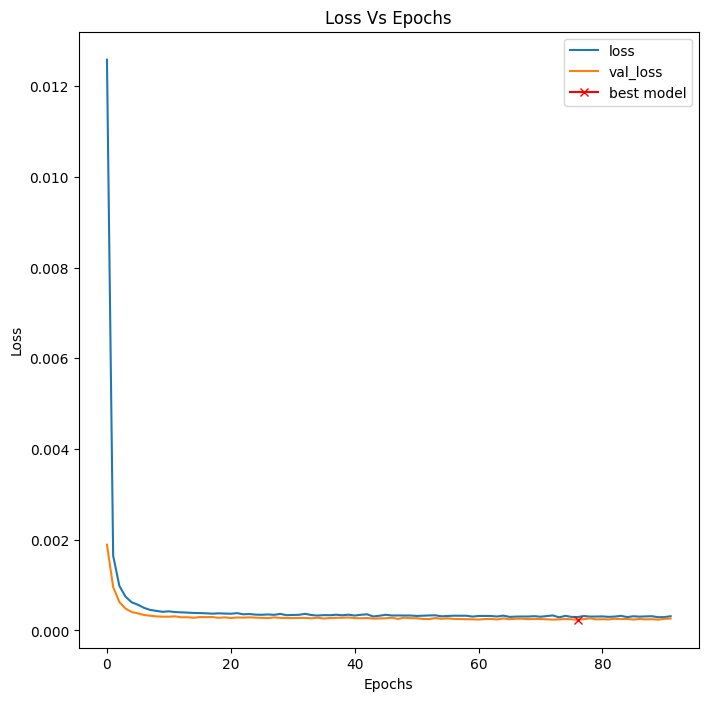

In [16]:
plt.figure(figsize=(8,8))
plt.title("Loss Vs Epochs")
plt.plot(train_losses, label="loss")
plt.plot(val_losses, label="val_loss")
plt.plot( np.argmin(val_losses), np.min(val_losses), marker="x", color="r", label="best model")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

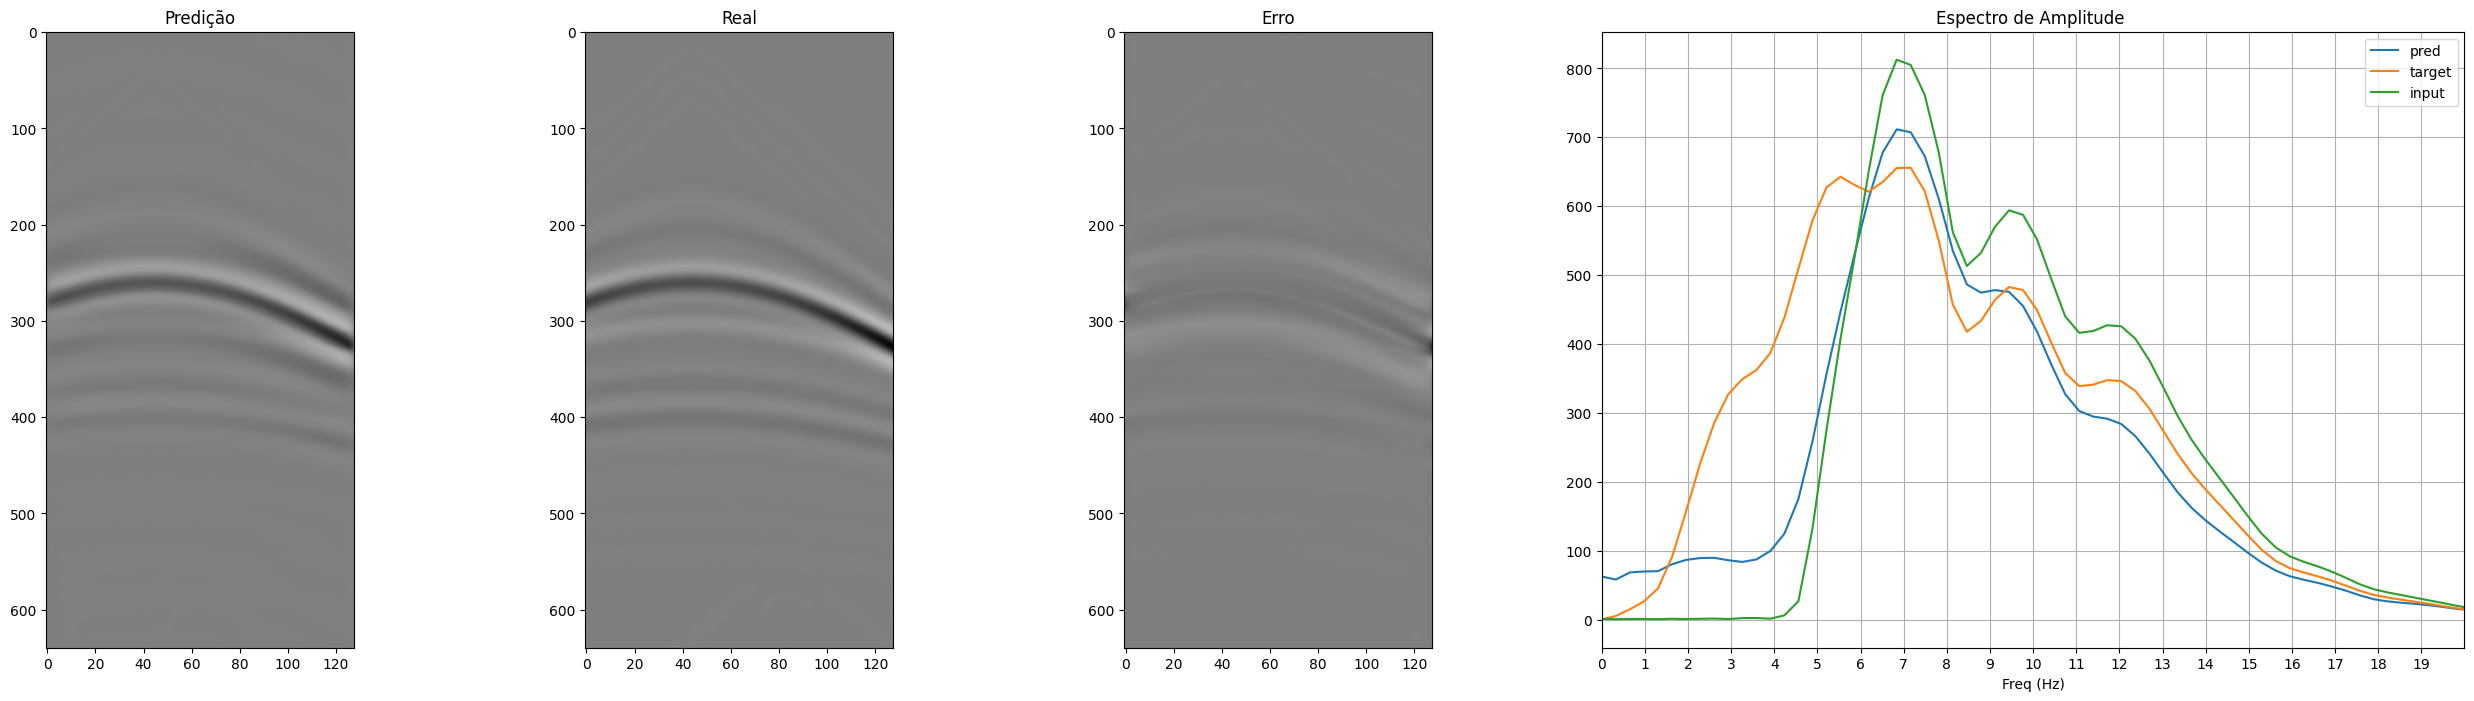

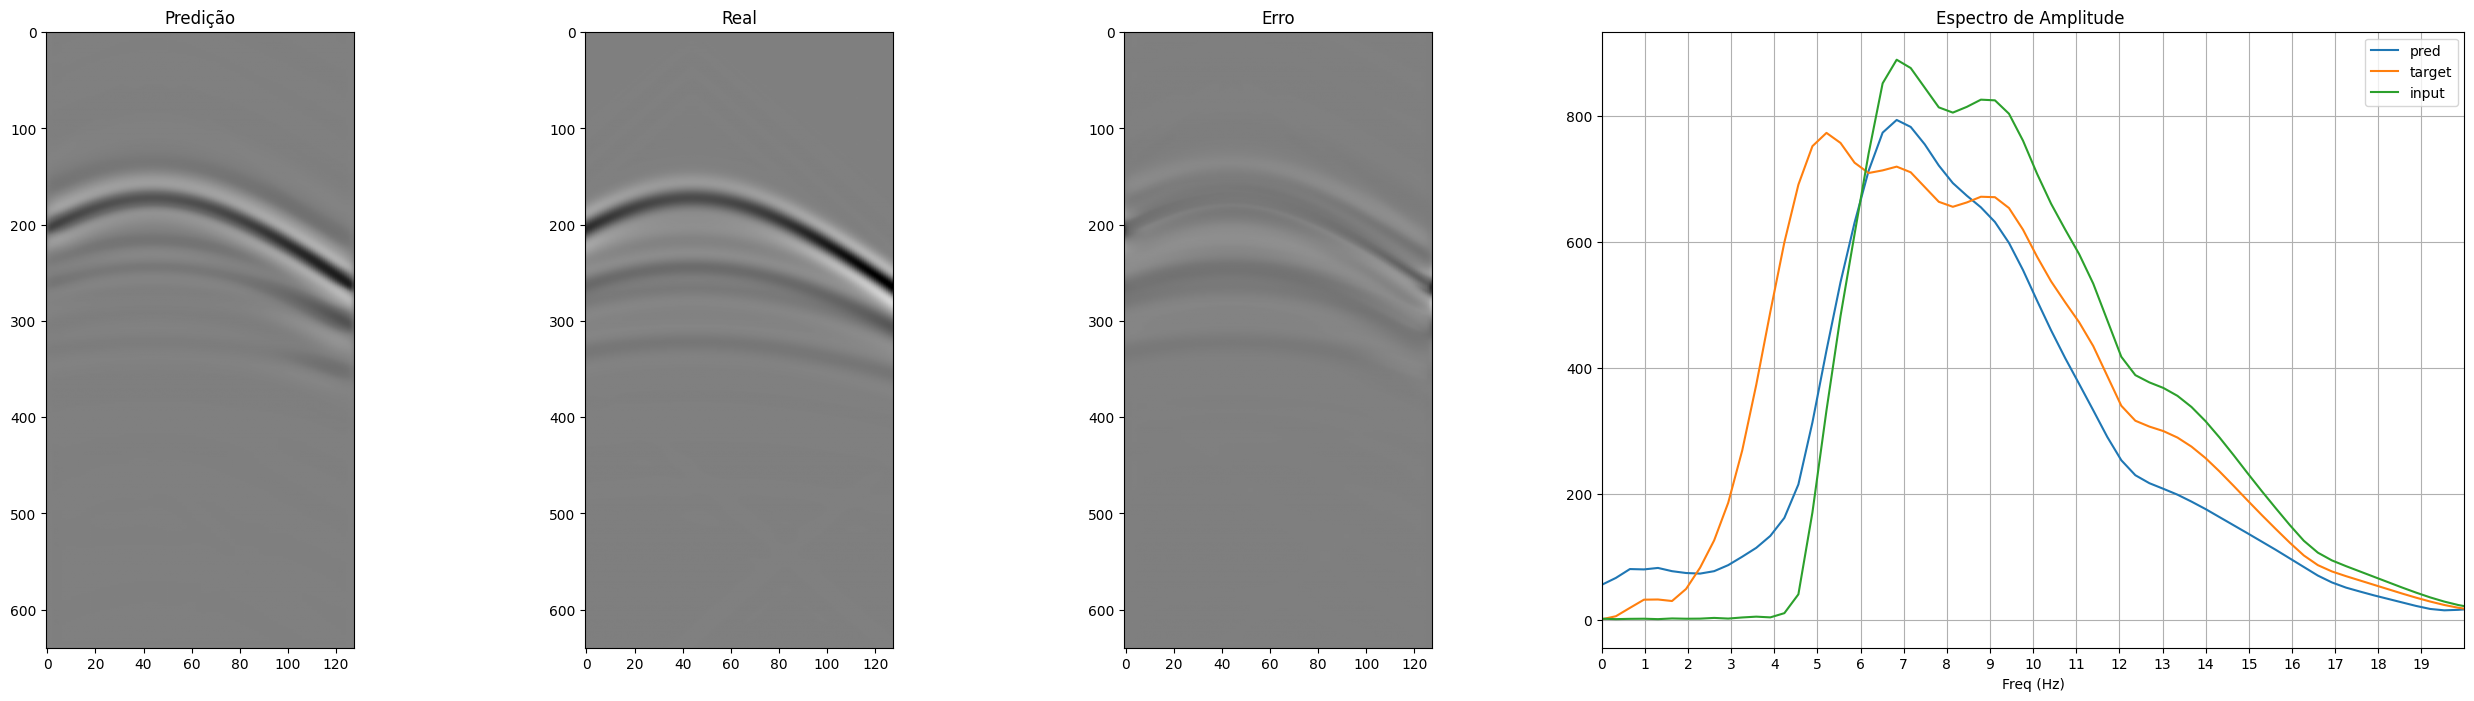

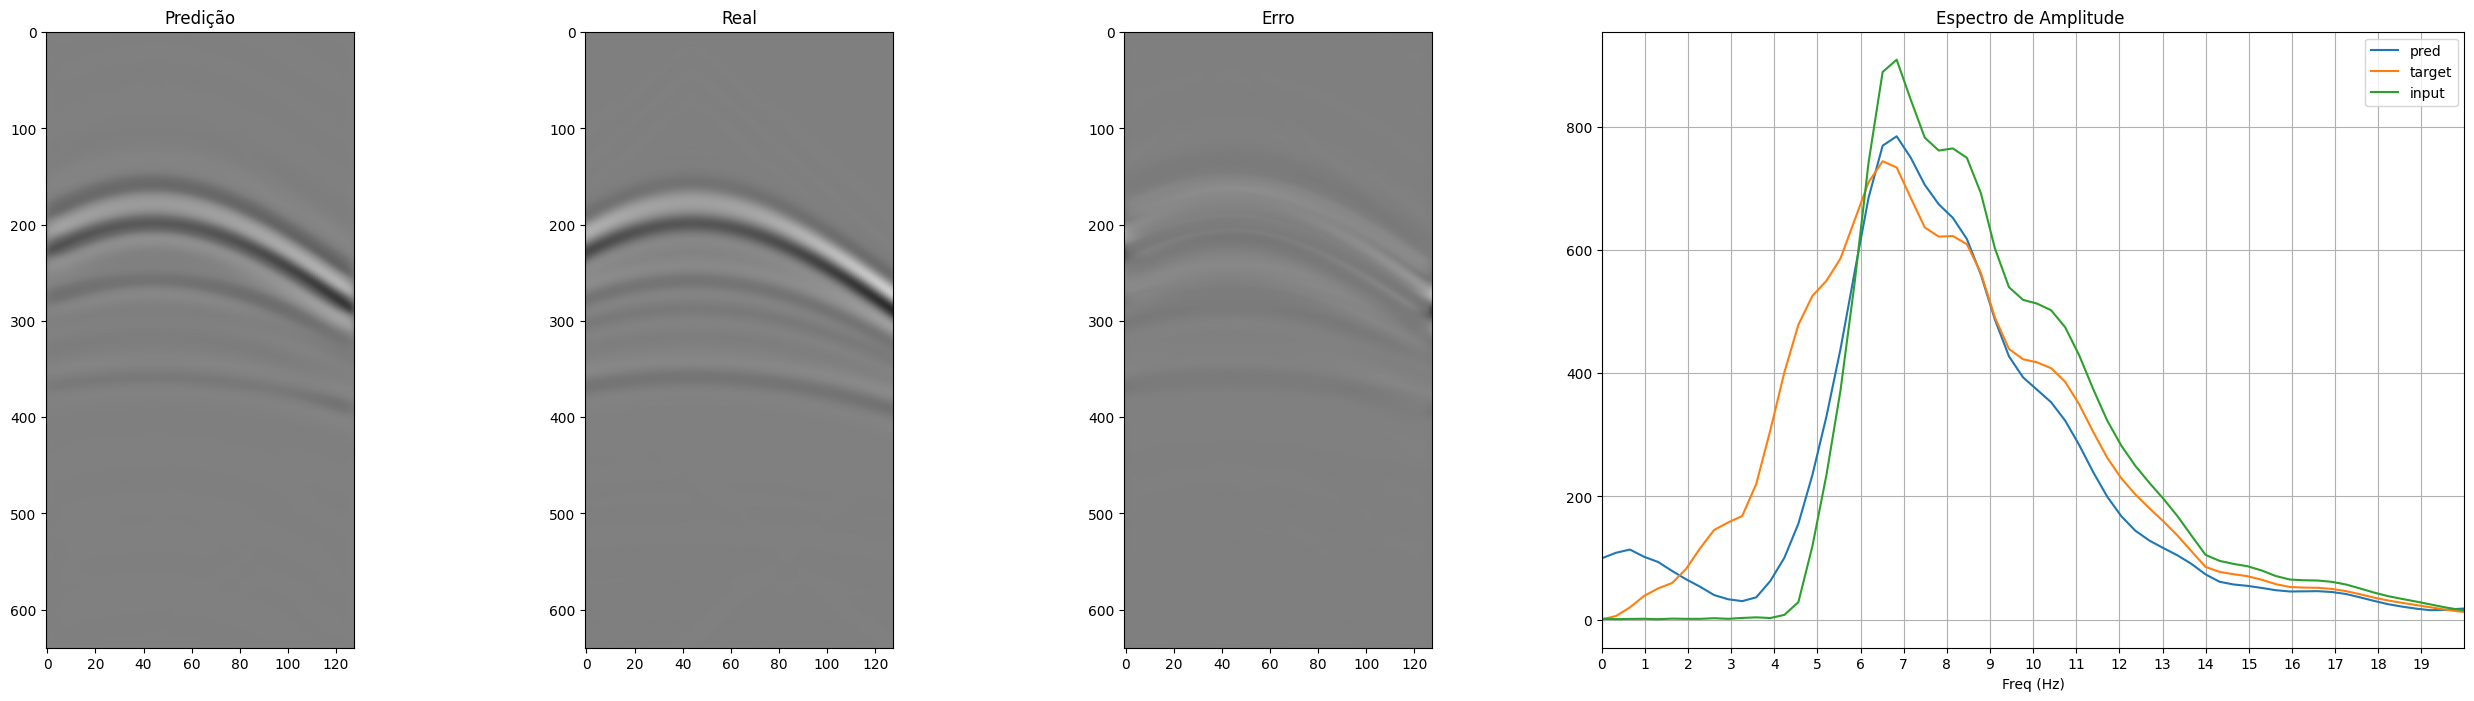

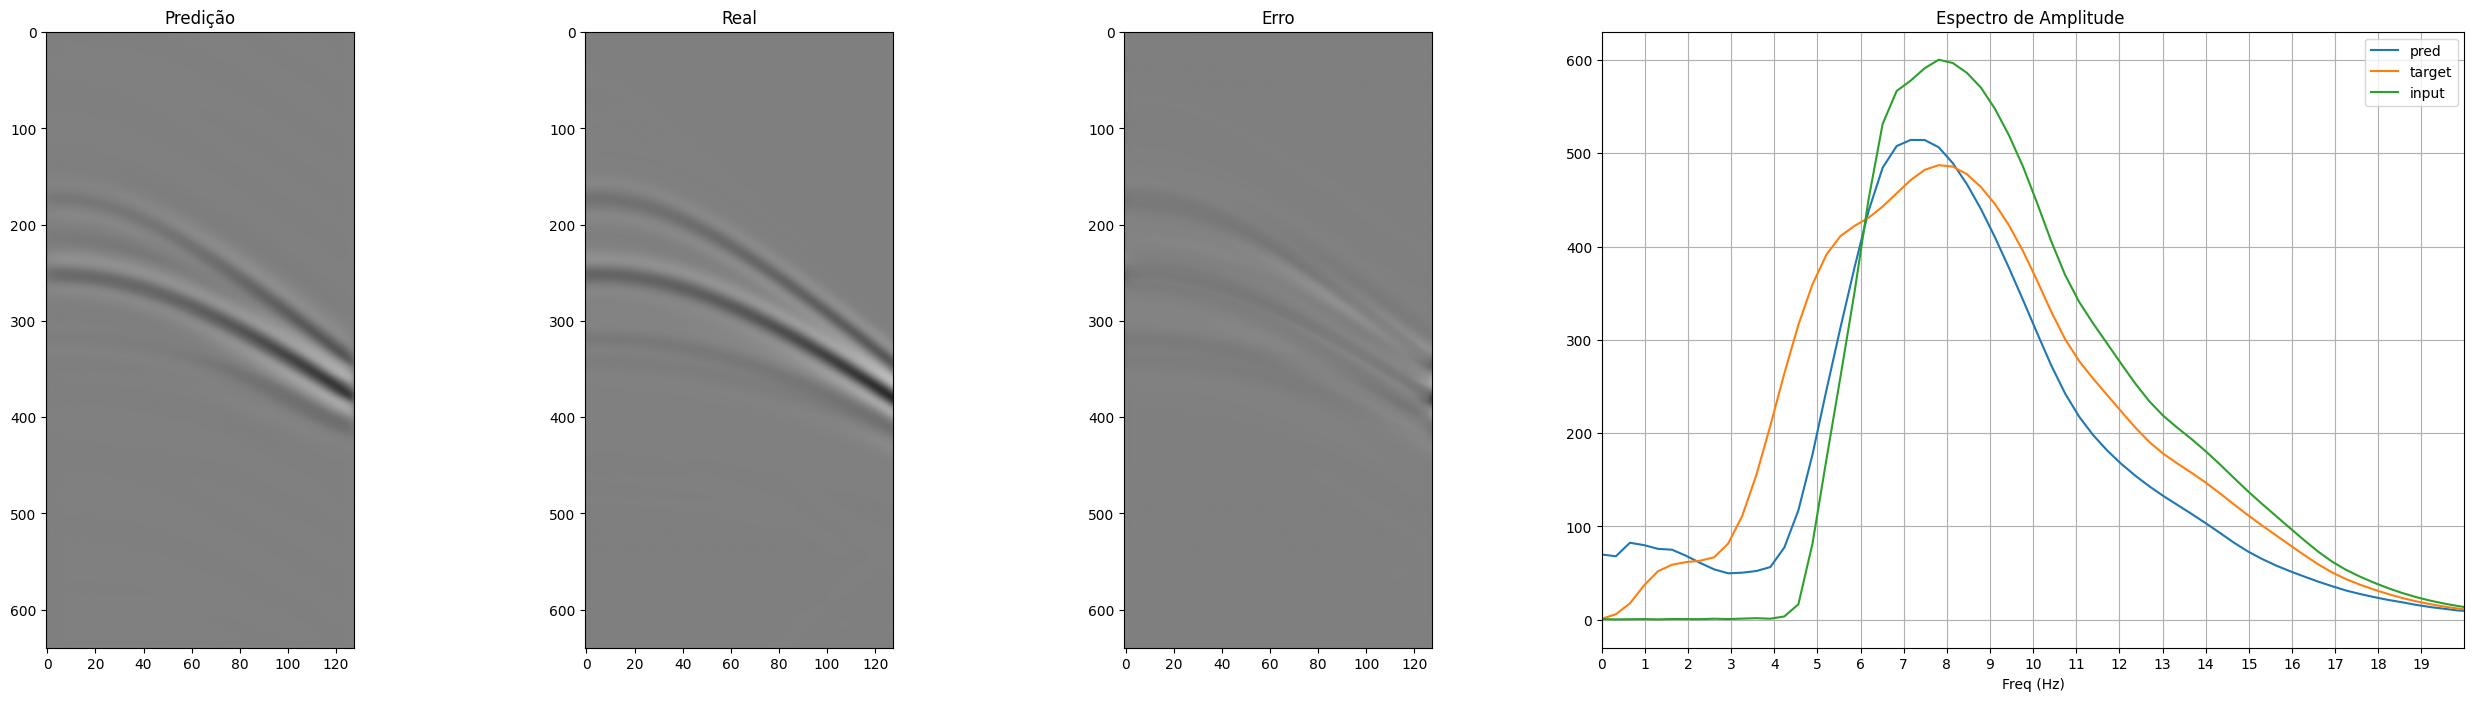

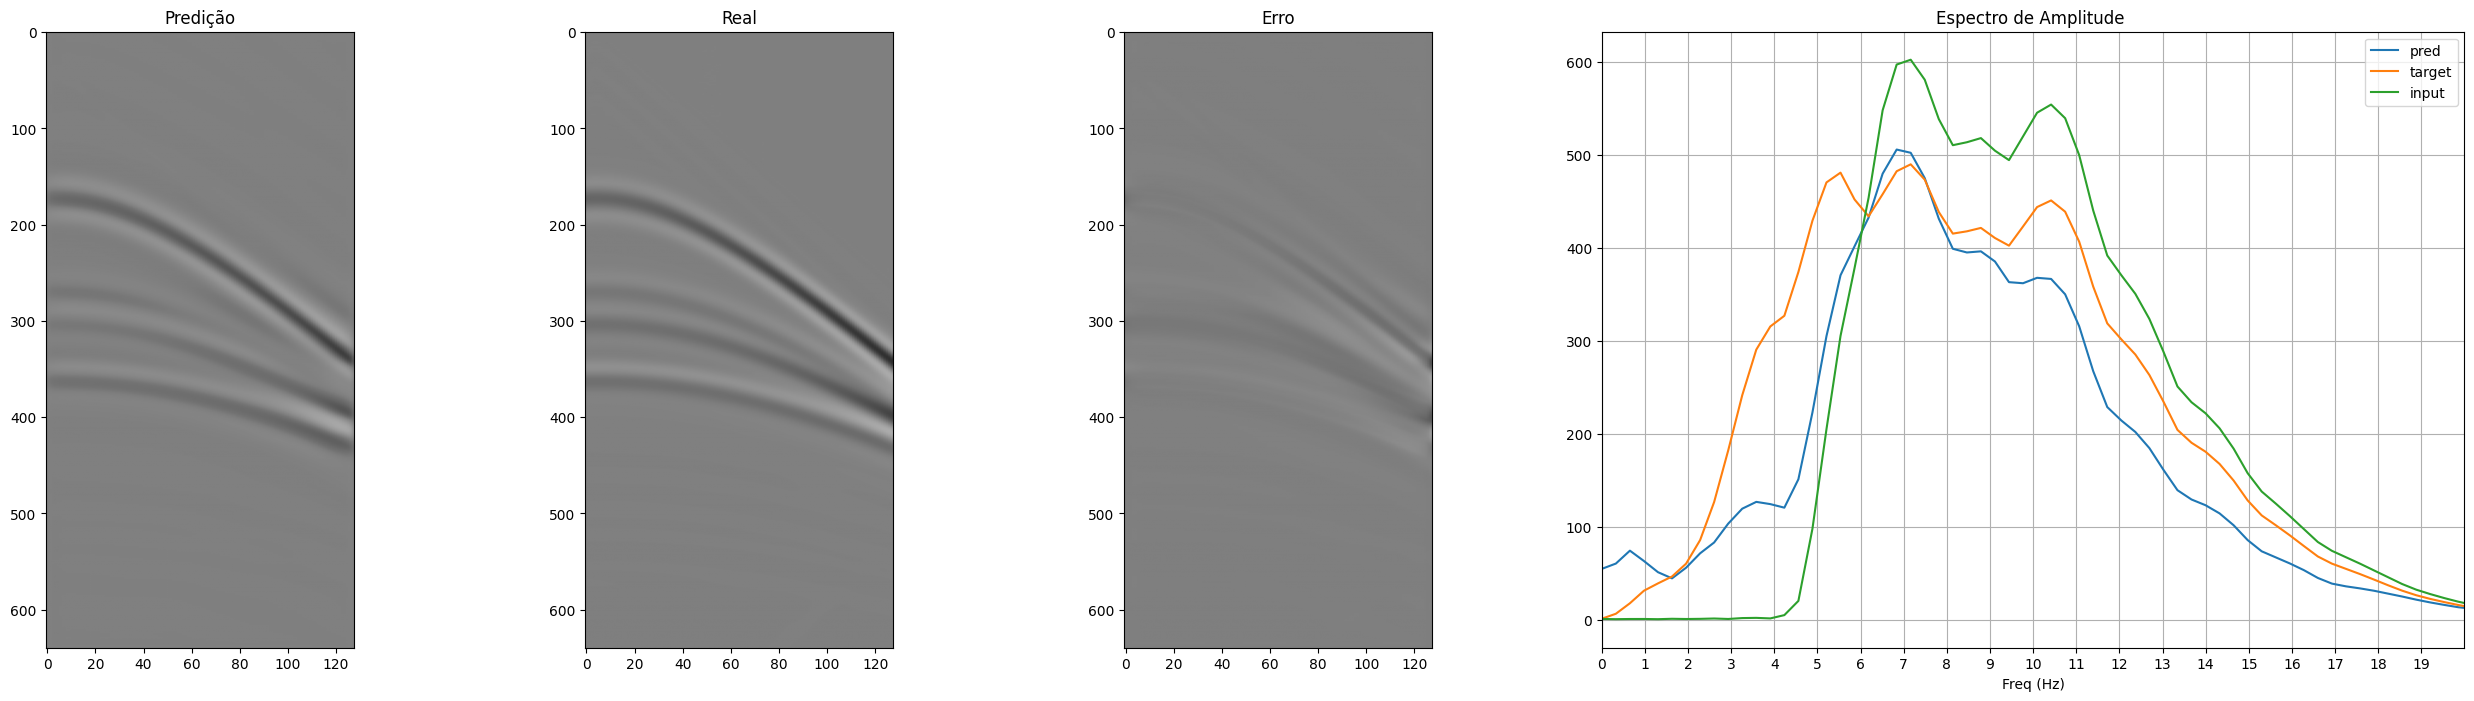

In [17]:
model.load_state_dict(torch.load(modelpath+'.pth'))
model.eval()
aspect=0.4
scale=0.5
pred = model(torch.tensor(x_test, dtype=torch.float32,device=device))
pred_cpu=pred.detach().cpu().numpy()
dt = 0.0030
freq = torch.fft.rfftfreq(1024, dt)
for n_image in range(len(x_test)):
    fig = plt.figure(figsize=(32,8))
    gs = fig.add_gridspec(1, 4,width_ratios=[1, 1, 1, 2])
    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[0, 1])
    ax3 = fig.add_subplot(gs[0, 2])
    ax4 = fig.add_subplot(gs[0, 3])
    DATA1 = torch.sum(torch.abs(torch.fft.rfft(torch.tensor(pred_cpu[n_image,0,:,:]), 1024,dim=0)),dim=1)
    DATA2 = torch.sum(torch.abs(torch.fft.rfft(torch.tensor(y_test[n_image,0,:,:]), 1024,dim=0)),dim=1)
    DATA3 = torch.sum(torch.abs(torch.fft.rfft(torch.tensor(x_test[n_image,0,:,:]), 1024,dim=0)),dim=1)

    ax1.imshow(pred_cpu[n_image,0,:,:],aspect=aspect,cmap="gray",vmin=-scale,vmax=scale)
    ax1.set_title('Predição')
    ax2.imshow(y_test[n_image,0,:,:],aspect=aspect,cmap="gray",vmin=-scale,vmax=scale)
    ax2.set_title('Real')
    ax3.imshow(y_test[n_image,0,:,:]-pred_cpu[n_image,0,:,:],aspect=aspect, cmap="gray",vmin=-scale,vmax=scale)
    ax3.set_title('Erro')
    ax4.plot(freq, DATA1, label='pred')
    ax4.plot(freq, DATA2, label='target')
    ax4.plot(freq, DATA3, label='input')
    ax4.grid()
    ax4.set_xlim(0,20)
    ax4.set_xlabel('Freq (Hz)')
    ax4.set_xticks(range(0, 20, 1))
    ax4.set_title('Espectro de Amplitude ')
    ax4.legend()
    fig = plt.gcf()
    plt.show()

In [18]:
model = UNet(in_channels=1, n_filters=16,dropout=0.2,moment=0.2,batchnorm=False)
model = model.to(device)
modelpath='model_l1_freq'
criterion1 = nn.L1Loss()
criterion2 = FreqLoss(patchshape)
optimizer = Adam(model.parameters(),lr=1e-4,weight_decay=2e-4)

best_val_loss = float("inf")
counter = 0
train_losses = []
val_losses = []
train_maes = []
val_maes = []
for epoch in range(EPOCAS):
    # ======================
    # TREINO
    # ======================
    model.train()
    running_loss = 0.0
    running_mae = 0.0
    for images, targets in train_loader:
        images = images.to(device)
        targets = targets.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion1(outputs, targets)+criterion2(outputs, targets)
        loss.backward()
        optimizer.step()
        mae = torch.mean(torch.abs(outputs - targets))
        running_loss += loss.item()
        running_mae += mae.item()

    epoch_train_loss = running_loss / len(train_loader)
    epoch_train_mae = running_mae / len(train_loader)
    # ======================
    # VALIDAÇÃO
    # ======================
    model.eval()
    running_val_loss = 0.0
    running_val_mae = 0.0
    with torch.no_grad():
        for images, targets in val_loader:
            images = images.to(device)
            targets = targets.to(device)
            outputs = model(images)
            loss = criterion1(outputs, targets)+criterion2(outputs, targets)
            mae = torch.mean(torch.abs(outputs - targets))
            running_val_loss += loss.item()
            running_val_mae += mae.item()
    epoch_val_loss = running_val_loss / len(val_loader)
    epoch_val_mae = running_val_mae / len(val_loader)

    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)
    train_maes.append(epoch_train_mae)
    val_maes.append(epoch_val_mae)

    print(
        f"Epoch [{epoch+1}/{EPOCAS}] "
        f"loss={epoch_train_loss:.4f} "
        f"mae={epoch_train_mae:.4f} "
        f"val_loss={epoch_val_loss:.4f} "
        f"val_mae={epoch_val_mae:.4f}"
    )

    # ======================
    # MODEL CHECKPOINT
    # ======================
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(),modelpath+'.pth')
        print(f"Val loss melhorou para {best_val_loss:.6f}. "f"Salvando modelo.")
        counter = 0
    else:
        counter += 1

        print(f"Val loss não melhorou. "f"Patience {counter}/{PATIENCE}")

        # ======================
        # EARLY STOPPING
        # ======================
        if counter >= PATIENCE:

            print("Early stopping!")
            break
np.save(modelpath+"_val_loss.npy", val_losses)
np.save(modelpath+"_train_loss.npy", train_losses)

Epoch [1/100] loss=0.4730 mae=0.1154 val_loss=0.1768 val_mae=0.0264
Val loss melhorou para 0.176788. Salvando modelo.
Epoch [2/100] loss=0.1254 mae=0.0261 val_loss=0.0653 val_mae=0.0152
Val loss melhorou para 0.065346. Salvando modelo.
Epoch [3/100] loss=0.0801 mae=0.0196 val_loss=0.0506 val_mae=0.0123
Val loss melhorou para 0.050610. Salvando modelo.
Epoch [4/100] loss=0.0678 mae=0.0166 val_loss=0.0515 val_mae=0.0131
Val loss não melhorou. Patience 1/15
Epoch [5/100] loss=0.0610 mae=0.0151 val_loss=0.0422 val_mae=0.0107
Val loss melhorou para 0.042173. Salvando modelo.
Epoch [6/100] loss=0.0566 mae=0.0139 val_loss=0.0590 val_mae=0.0161
Val loss não melhorou. Patience 1/15
Epoch [7/100] loss=0.0516 mae=0.0124 val_loss=0.0464 val_mae=0.0125
Val loss não melhorou. Patience 2/15
Epoch [8/100] loss=0.0483 mae=0.0115 val_loss=0.0546 val_mae=0.0152
Val loss não melhorou. Patience 3/15
Epoch [9/100] loss=0.0446 mae=0.0105 val_loss=0.0544 val_mae=0.0149
Val loss não melhorou. Patience 4/15
Epo

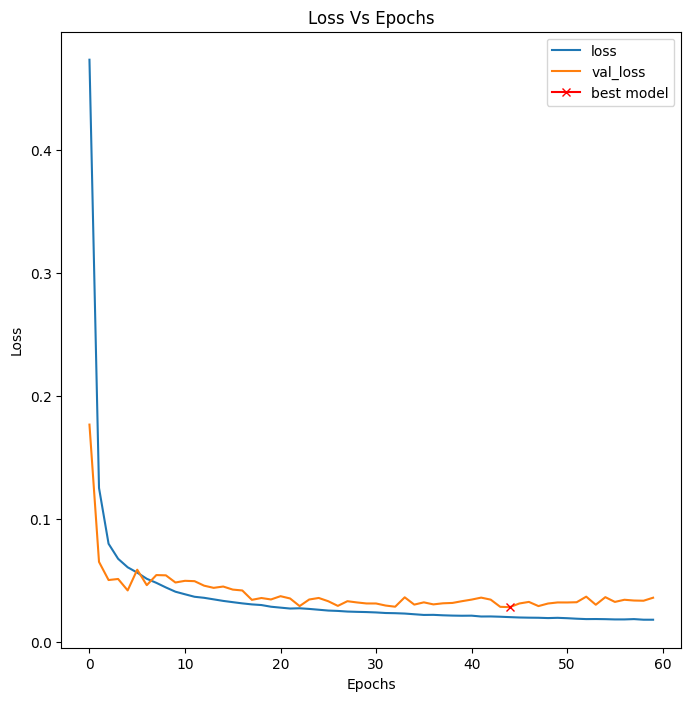

In [19]:
plt.figure(figsize=(8,8))
plt.title("Loss Vs Epochs")
plt.plot(train_losses, label="loss")
plt.plot(val_losses, label="val_loss")
plt.plot( np.argmin(val_losses), np.min(val_losses), marker="x", color="r", label="best model")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

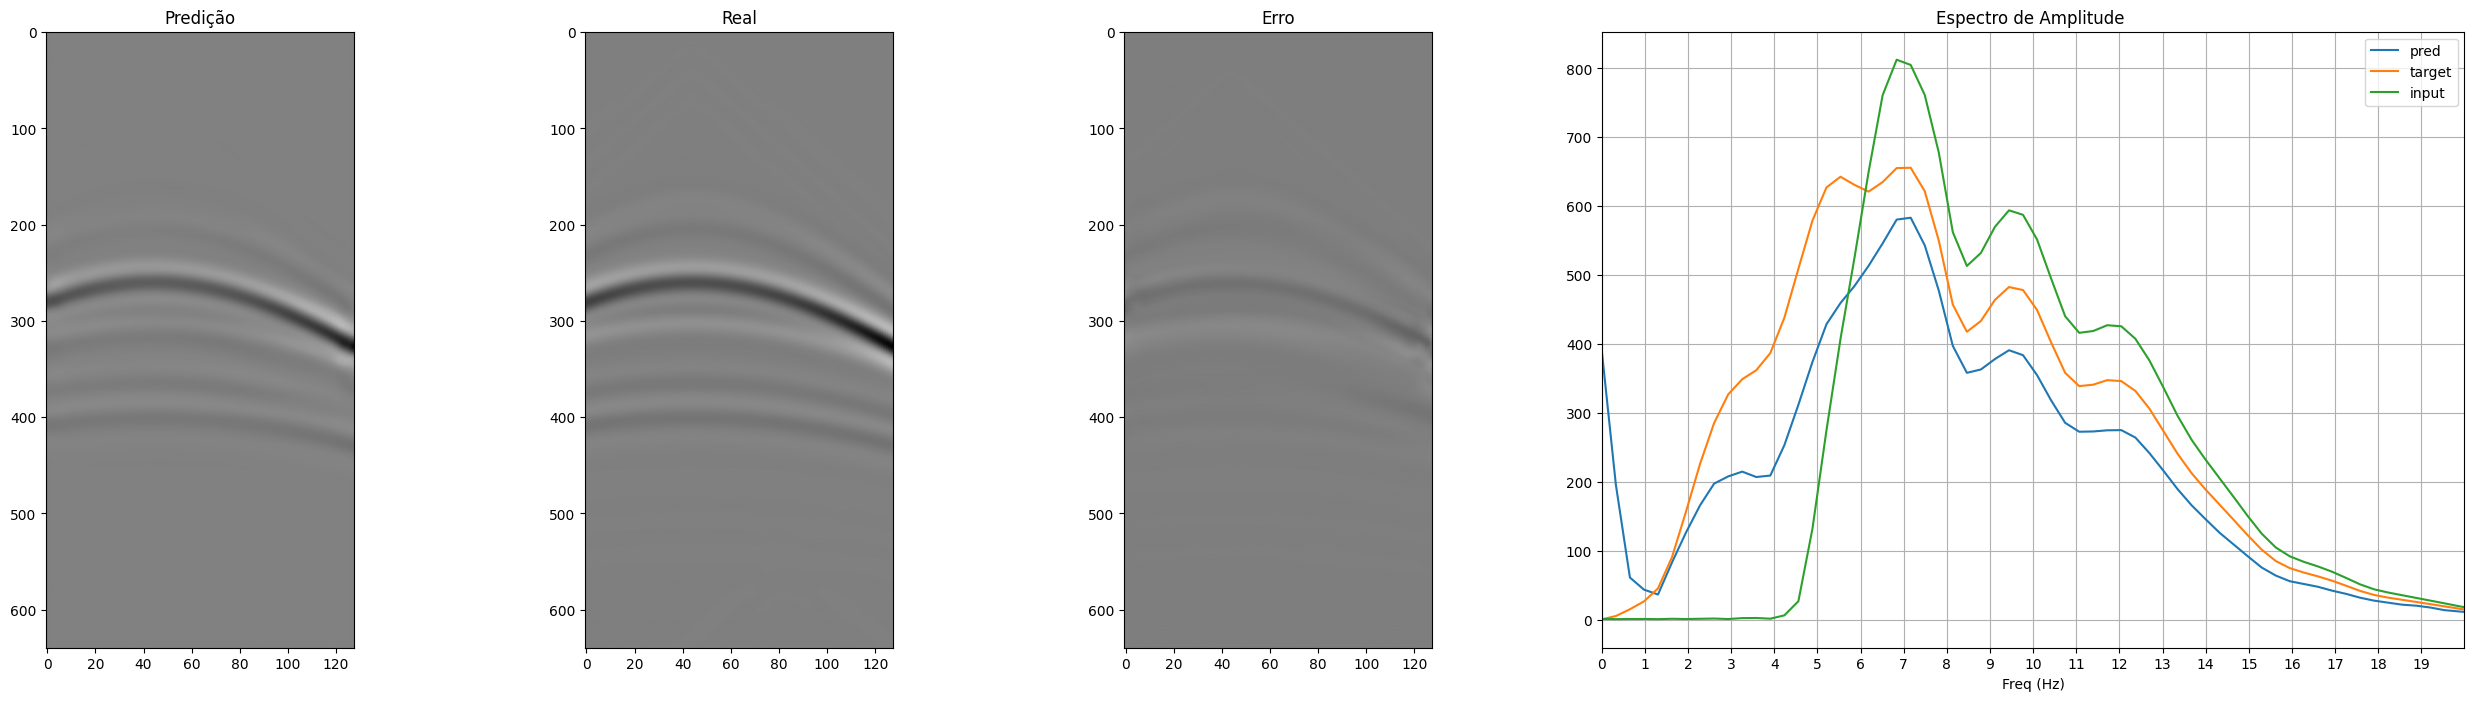

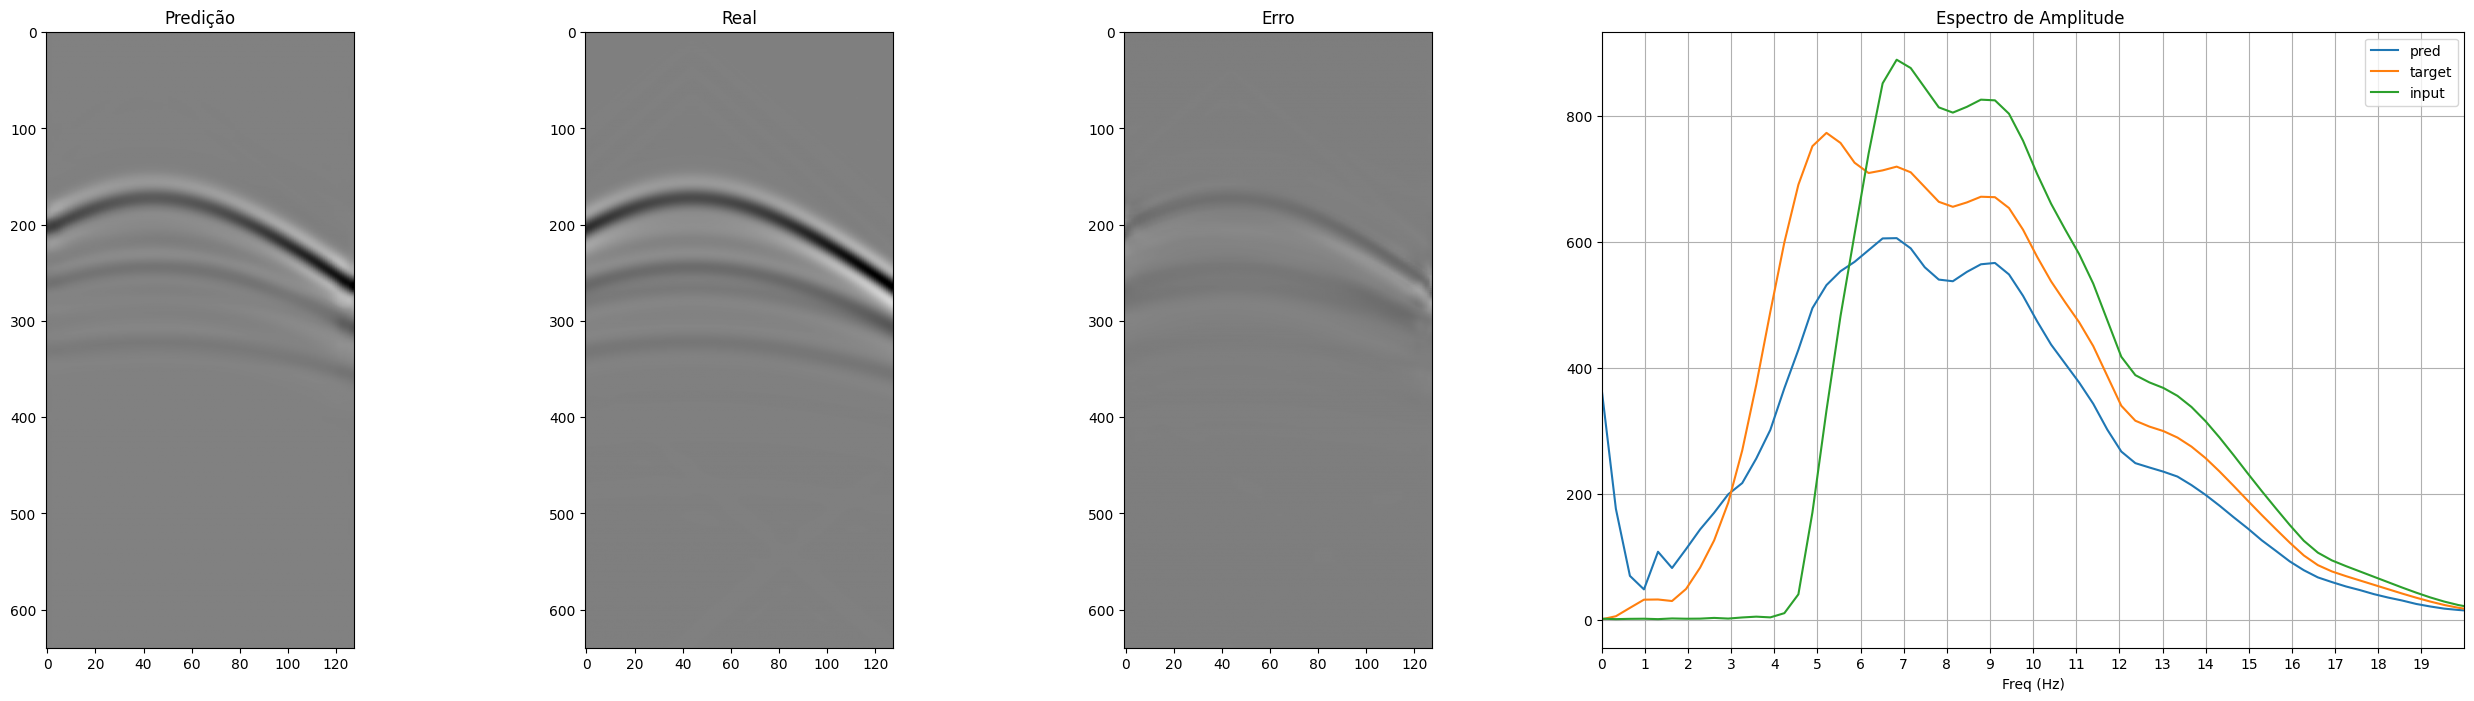

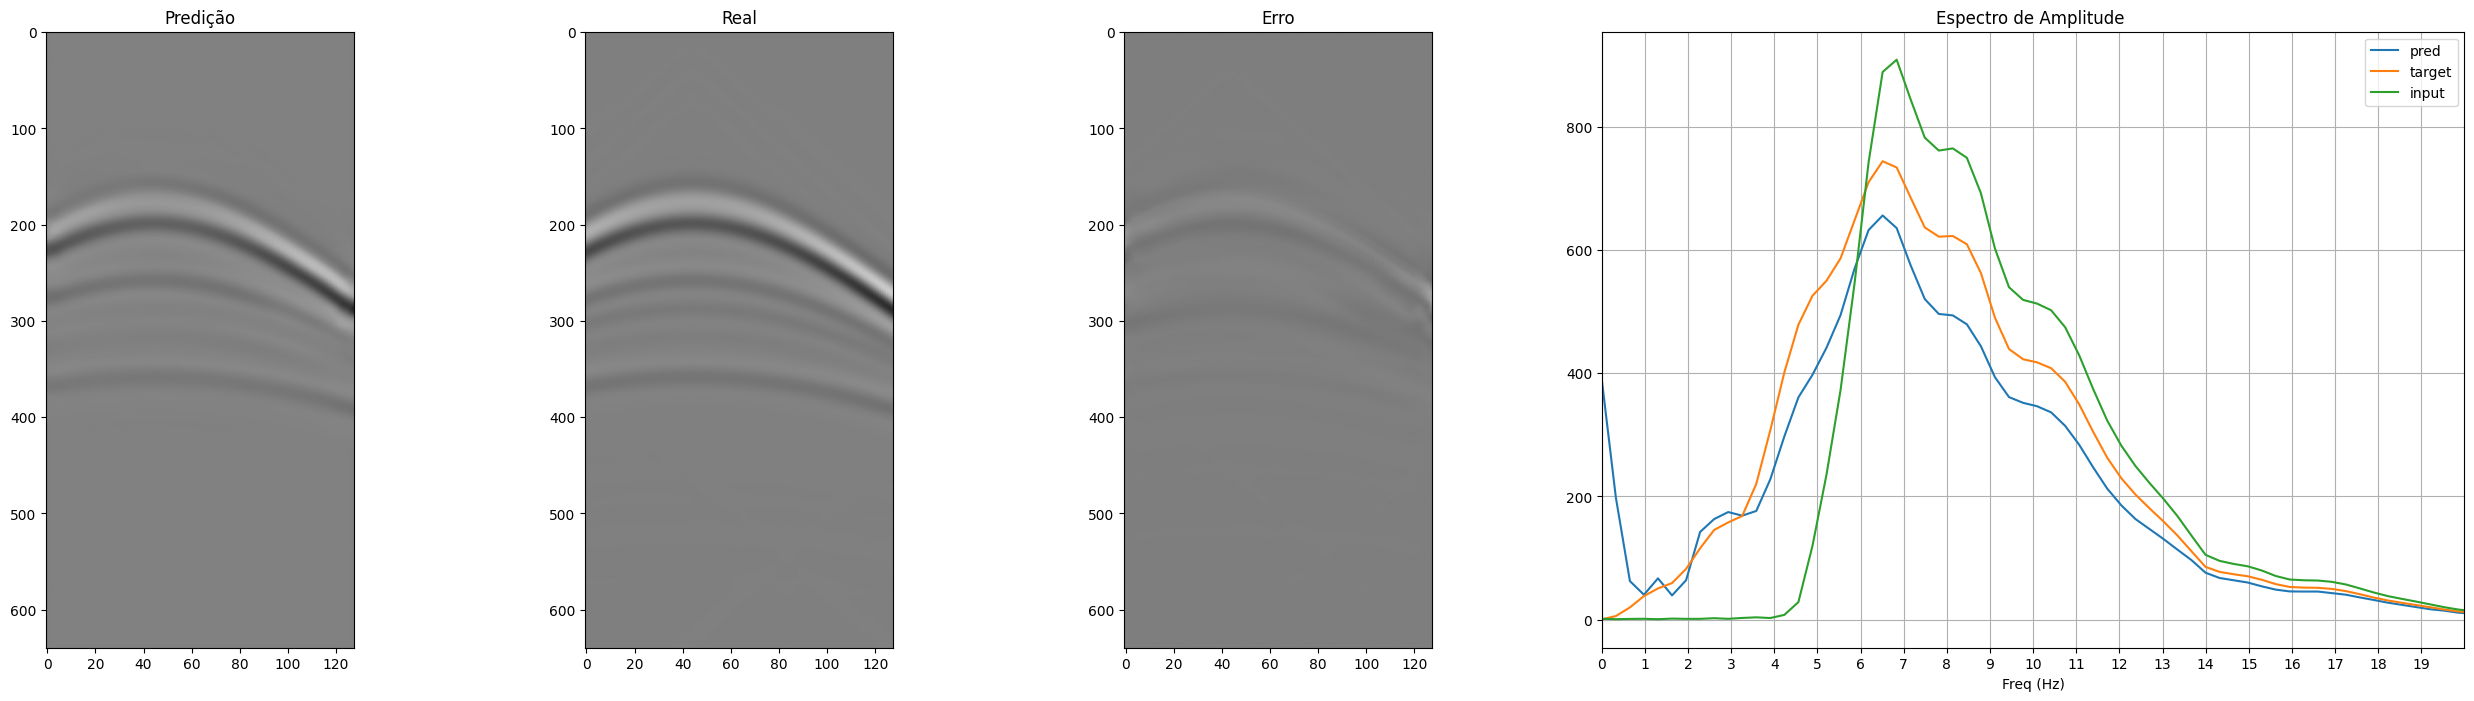

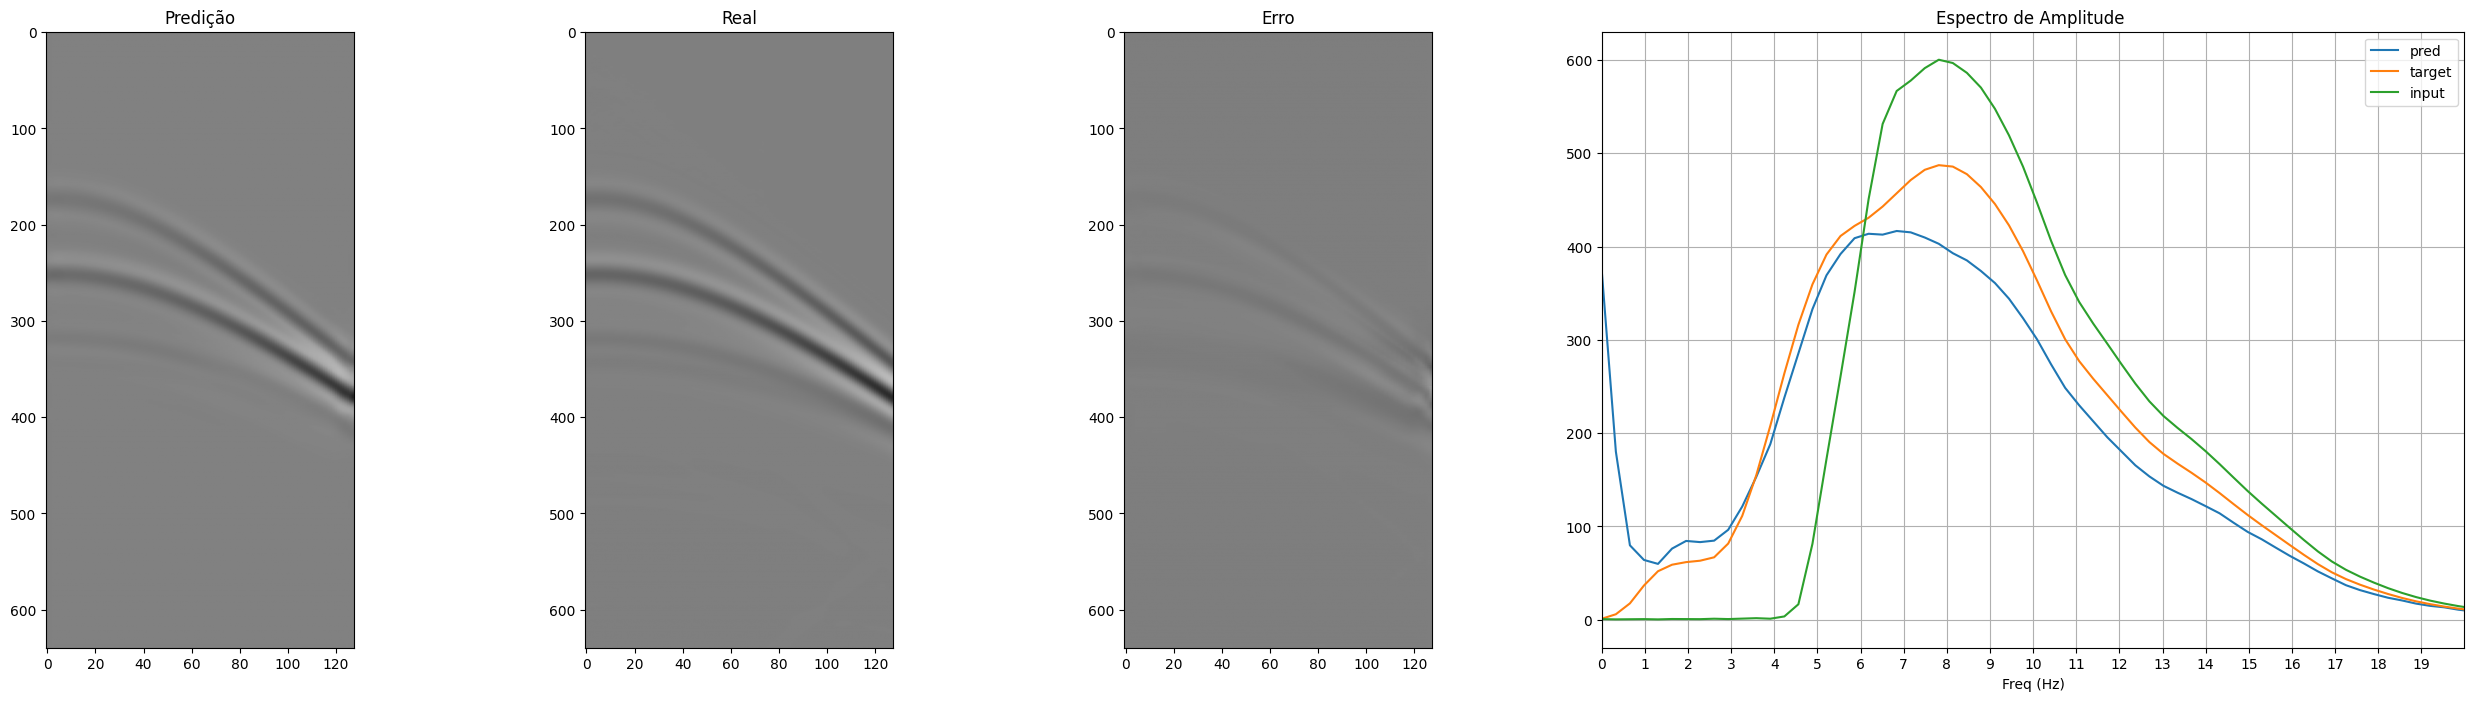

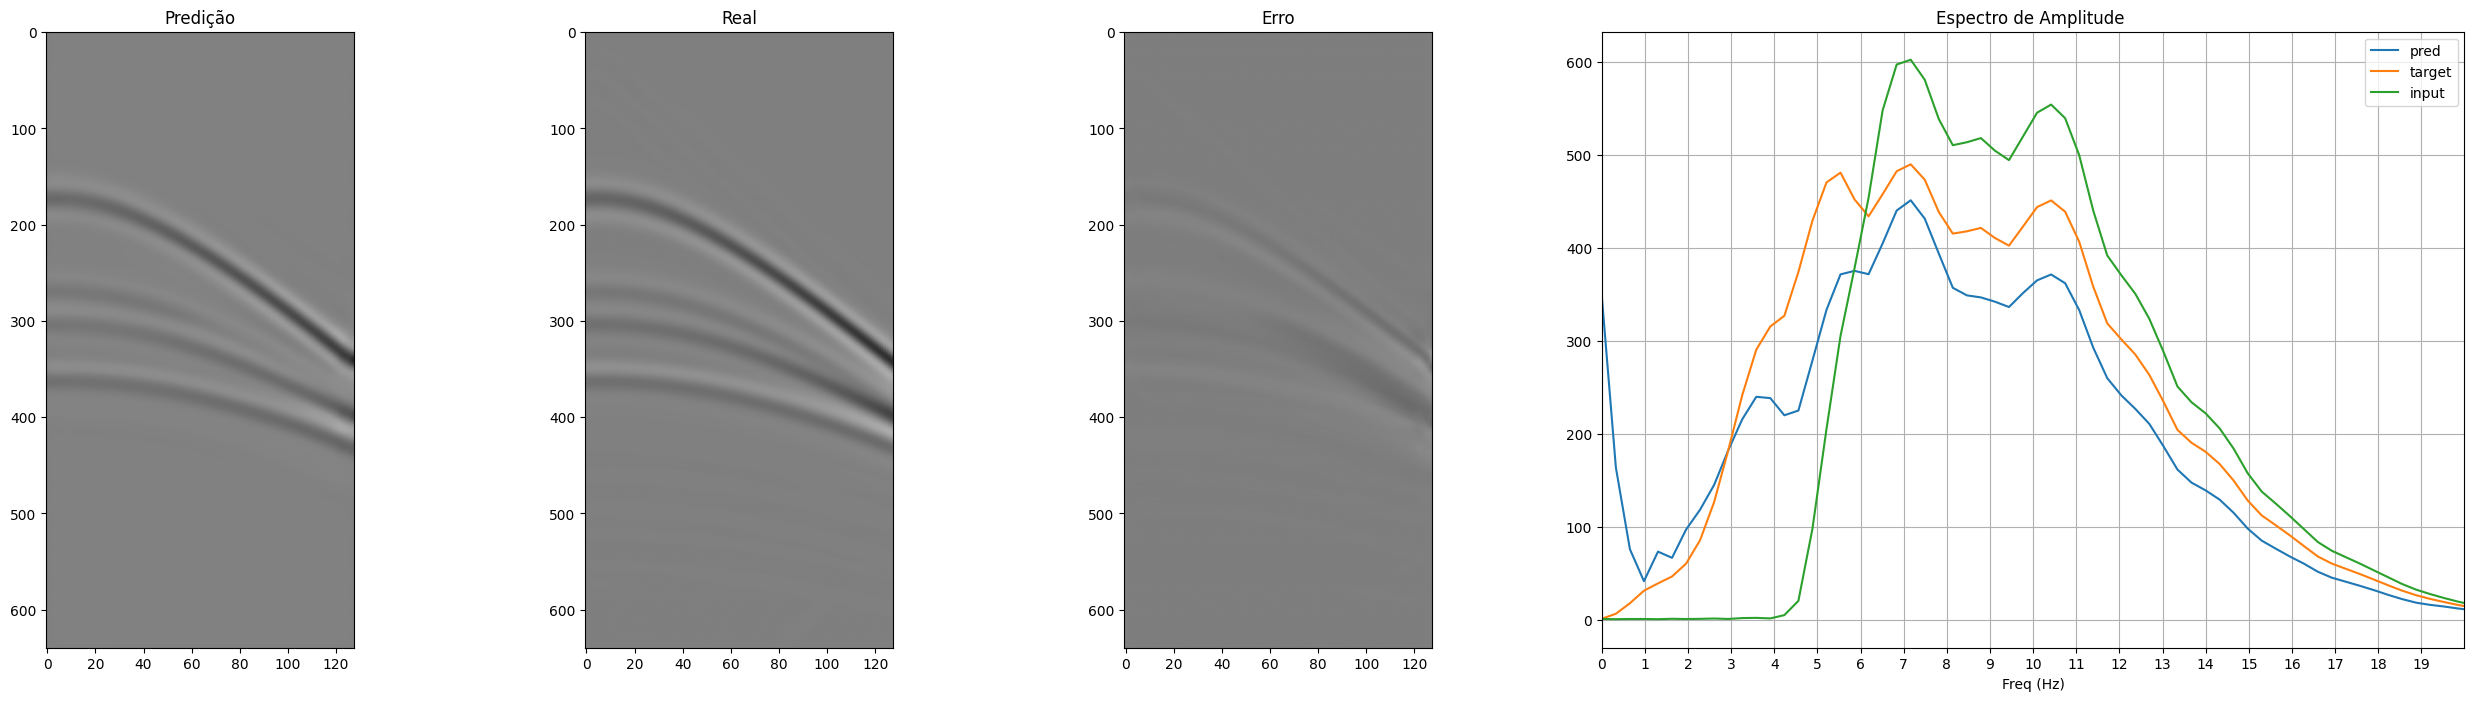

In [20]:
model.load_state_dict(torch.load(modelpath+'.pth'))
model.eval()
aspect=0.4
scale=0.5
pred = model(torch.tensor(x_test, dtype=torch.float32,device=device))
pred_cpu=pred.detach().cpu().numpy()
dt = 0.0030
freq = torch.fft.rfftfreq(1024, dt)
for n_image in range(len(x_test)):
    fig = plt.figure(figsize=(32,8))
    gs = fig.add_gridspec(1, 4,width_ratios=[1, 1, 1, 2])
    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[0, 1])
    ax3 = fig.add_subplot(gs[0, 2])
    ax4 = fig.add_subplot(gs[0, 3])
    DATA1 = torch.sum(torch.abs(torch.fft.rfft(torch.tensor(pred_cpu[n_image,0,:,:]), 1024,dim=0)),dim=1)
    DATA2 = torch.sum(torch.abs(torch.fft.rfft(torch.tensor(y_test[n_image,0,:,:]), 1024,dim=0)),dim=1)
    DATA3 = torch.sum(torch.abs(torch.fft.rfft(torch.tensor(x_test[n_image,0,:,:]), 1024,dim=0)),dim=1)

    ax1.imshow(pred_cpu[n_image,0,:,:],aspect=aspect,cmap="gray",vmin=-scale,vmax=scale)
    ax1.set_title('Predição')
    ax2.imshow(y_test[n_image,0,:,:],aspect=aspect,cmap="gray",vmin=-scale,vmax=scale)
    ax2.set_title('Real')
    ax3.imshow(y_test[n_image,0,:,:]-pred_cpu[n_image,0,:,:],aspect=aspect, cmap="gray",vmin=-scale,vmax=scale)
    ax3.set_title('Erro')
    ax4.plot(freq, DATA1, label='pred')
    ax4.plot(freq, DATA2, label='target')
    ax4.plot(freq, DATA3, label='input')
    ax4.grid()
    ax4.set_xlim(0,20)
    ax4.set_xlabel('Freq (Hz)')
    ax4.set_xticks(range(0, 20, 1))
    ax4.set_title('Espectro de Amplitude ')
    ax4.legend()
    fig = plt.gcf()
    plt.show()